**S.H.I.E.L.D**

LSTM Training Pipeline

In [1]:
import os
from google.colab import userdata

# Replace with the URL of the GitHub repository you want to clone
github_repo_url = "https://github.com/sivrox/SHIELD_CPP_AIModel"

# Replace with the name of the branch you want to clone (e.g., 'main', 'development')
github_branch_name = "Final-LSTM-and-FL-Framework"

# Retrieve GitHub Token securely from Colab secrets
# Make sure you have added a secret named 'GITHUB_TOKEN' with your PAT
github_token = userdata.get('GITHUB_TOKEN')

# Construct the authenticated GitHub URL
# This assumes the token has the necessary permissions (e.g., 'repo' scope)
authenticated_repo_url = github_repo_url.replace("https://", f"https://oauth2:{github_token}@")

# Clone the repository and specified branch
!git clone --single-branch -b {github_branch_name} {authenticated_repo_url}

# After cloning, you can list the contents of the new directory
# For example, if the repo name is 'SHIELD_CPP_AIModel', you can do:
!ls SHIELD_CPP_AIModel

fatal: destination path 'SHIELD_CPP_AIModel' already exists and is not an empty directory.
'LSTM Model'   README.md	    shield_medical_db
'RAG Model'    shield_dataset.csv   shield_v3.h5


Config Setup

In [2]:
!pip install flwr shap -q

In [4]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, classification_report, mean_absolute_error)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.makedirs('/content/outputs', exist_ok=True)
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Load Training Dataset

In [7]:
csv_path = 'SHIELD_CPP_AIModel/LSTM_Model/shield_training_dataset.csv'
df = pd.read_csv(csv_path)
print(f"Dataset: {df.shape[0]:,} rows, {df['patient_id'].nunique()} patients")
print(f"Columns: {df.columns.tolist()}")
print(f"Stress score range: {df['stress_score'].min():.4f} - {df['stress_score'].max():.4f}")

Dataset: 1,036,800 rows, 30 patients
Columns: ['patient_id', 'hospital_id', 'timestamp', 'age', 'hr', 'hrv', 'spo2', 'bp_s', 'bp_d', 'activity', 'sleep', 'stress_score']
Stress score range: 0.0242 - 0.9672


Feature Engineering and Normalization

In [8]:
#Feature columns in the exact order the app expects
feature_order = ['hr', 'bp_s', 'hrv', 'bp_d', 'spo2', 'activity', 'age', 'sleep']
target_col = 'stress_score'
window_size = 60  # 60 timesteps = 60 seconds at 5-sec intervals (paper spec)

#Compute scaler stats from training data (will be saved for the app)
#Activity is categorical — not scaled
scaler_stats = {}
for col in feature_order:
    if col == 'activity':
        scaler_stats['activity_level'] = {
            "mean": 0.0, "std": 1.0, "type": "categorical"}
    else:
        scaler_stats[col] = {
            "mean": float(df[col].mean()),
            "std": float(df[col].std()),
            "type": "numerical"}

print("\nScaler Stats (will be saved for the app):")
for k, v in scaler_stats.items():
    print(f"{k}: mean={v['mean']:.2f}, std={v['std']:.2f}, type={v['type']}")

#Apply z-score normalization
df_scaled = df.copy()
for col in feature_order:
    if col != 'activity':
        key = col
        df_scaled[col] = (df[col] - scaler_stats[key]['mean']) / scaler_stats[key]['std']


Scaler Stats (will be saved for the app):
hr: mean=78.62, std=19.68, type=numerical
bp_s: mean=137.00, std=16.35, type=numerical
hrv: mean=92.87, std=10.76, type=numerical
bp_d: mean=95.45, std=16.32, type=numerical
spo2: mean=96.65, std=1.44, type=numerical
activity_level: mean=0.00, std=1.00, type=categorical
age: mean=43.87, std=15.72, type=numerical
sleep: mean=6.18, std=0.75, type=numerical


Build Sliding Window Sequence

In [9]:
#Build (window_size, 8) sequences from one patient's time-series
def build_sequences(patient_df, window_size=60, step=30):
    features = patient_df[feature_order].values
    targets = patient_df[target_col].values
    seqs, labels = [], []
    for i in range(0, len(features) - window_size, step):
        seqs.append(features[i:i + window_size])
        labels.append(targets[i + window_size - 1])  # label = last timestep
    return seqs, labels

#Split patients: 80% train, 20% test (no patient in both)
all_patients = df['patient_id'].unique()
np.random.seed(42)
np.random.shuffle(all_patients)
split_idx = int(len(all_patients) * 0.8)
train_patients = set(all_patients[:split_idx])
test_patients = set(all_patients[split_idx:])

print(f"\nTrain patients: {len(train_patients)}, Test patients: {len(test_patients)}")

#Build sequences
train_seqs, train_labels = [], []
test_seqs, test_labels = [], []

for pid in df['patient_id'].unique():
    patient_data = df_scaled[df_scaled['patient_id'] == pid].sort_values('timestamp')
    seqs, labels = build_sequences(patient_data, window_size, step=30)
    if pid in train_patients:
        train_seqs.extend(seqs)
        train_labels.extend(labels)
    else:
        test_seqs.extend(seqs)
        test_labels.extend(labels)

X_train = np.array(train_seqs, dtype=np.float32)
y_train = np.array(train_labels, dtype=np.float32)
X_test = np.array(test_seqs, dtype=np.float32)
y_test = np.array(test_labels, dtype=np.float32)

print(f"Training sequences: {X_train.shape} → {y_train.shape}")
print(f"Test sequences: {X_test.shape} → {y_test.shape}")
print(f"Memory: ~{(X_train.nbytes + X_test.nbytes) / 1e9:.1f} GB")


Train patients: 24, Test patients: 6
Training sequences: (27600, 60, 8) → (27600,)
Test sequences: (6900, 60, 8) → (6900,)
Memory: ~0.1 GB


Build LSTM Model

In [21]:
import tensorflow as tf

#Bidirectional LSTM for continuous stress score prediction.
def build_model(window_size=60, n_features=8):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(window_size, n_features)),

        #Bidirectional LSTM captures patterns in both time directions
        tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(64, return_sequences=True, implementation=2)),
        tf.keras.layers.Dropout(0.3),

        #Second LSTM layer collapses the sequence
        tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(32, return_sequences=False, implementation=2)),
        tf.keras.layers.Dropout(0.3),

        #Dense layers for final prediction
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',  # regression: predict continuous 0-1 score
        metrics=['mae'])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,217 (317.25 KB)

 Trainable params: 81,217 (317.25 KB)

 Non-trainable params: 0 (0.00 B)

Train Baseline Model for FL

Training Baseline Model...

Epoch 1/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0033 - mae: 0.0419 - val_loss: 0.0011 - val_mae: 0.0236 - learning_rate: 0.0010
Epoch 2/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0018 - mae: 0.0315 - val_loss: 9.3070e-04 - val_mae: 0.0225 - learning_rate: 0.0010
Epoch 3/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0014 - mae: 0.0279 - val_loss: 0.0014 - val_mae: 0.0304 - learning_rate: 0.0010
Epoch 4/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0012 - mae: 0.0254 - val_loss: 8.5252e-04 - val_mae: 0.0229 - learning_rate: 0.0010
Epoch 5/30
386/389 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0010 - mae: 0.0236
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 9.8344e-04 - mae: 0.0232 - val_loss: 0.0012 - val_mae: 0.0292 - learning_rate: 0.0010
Epoch 6/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 8.3709e-04 - mae: 0.0214 - val_loss: 

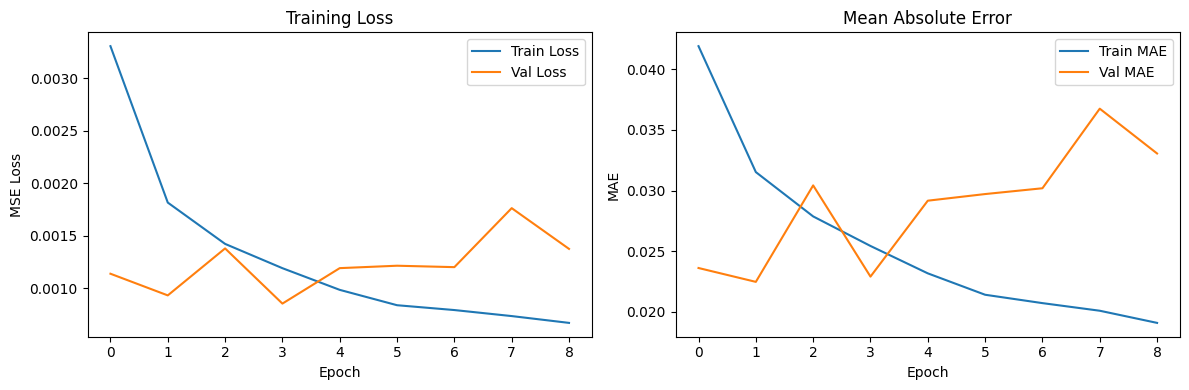

216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Centralized Model - MAE: 0.0217, AUROC: 0.9961


In [15]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

print("Training Baseline Model...\n")

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

#Save training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend(); plt.title('Training Loss')
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend(); plt.title('Mean Absolute Error')
plt.tight_layout()
plt.savefig('/content/outputs/training_history.png', dpi=150)
plt.show()

#Evaluate centralized model
centralized_pred = model.predict(X_test).flatten()
centralized_mae = mean_absolute_error(y_test, centralized_pred)
centralized_auroc = roc_auc_score((y_test > 0.5).astype(int), centralized_pred)
print(f"\nCentralized Model - MAE: {centralized_mae:.4f}, AUROC: {centralized_auroc:.4f}")

Federated Learning Simulation

Federated Learning Simulation

Flower library loaded successfully
Hospital 0: 9 patients, 10,350 sequences
Hospital 1: 7 patients, 8,050 sequences
Hospital 2: 8 patients, 9,200 sequences
Round 1/10 — MAE: 0.0399, AUROC: 0.9831
Round 2/10 — MAE: 0.0279, AUROC: 0.9933
Round 3/10 — MAE: 0.0278, AUROC: 0.9953
Round 4/10 — MAE: 0.0286, AUROC: 0.9963
Round 5/10 — MAE: 0.0270, AUROC: 0.9971
Round 6/10 — MAE: 0.0289, AUROC: 0.9978
Round 7/10 — MAE: 0.0258, AUROC: 0.9979
Round 8/10 — MAE: 0.0270, AUROC: 0.9982
Round 9/10 — MAE: 0.0275, AUROC: 0.9983
Round 10/10 — MAE: 0.0230, AUROC: 0.9981
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Final FL Model - MAE: 0.0230, AUROC: 0.9981
Centralized - MAE: 0.0217, AUROC: 0.9961


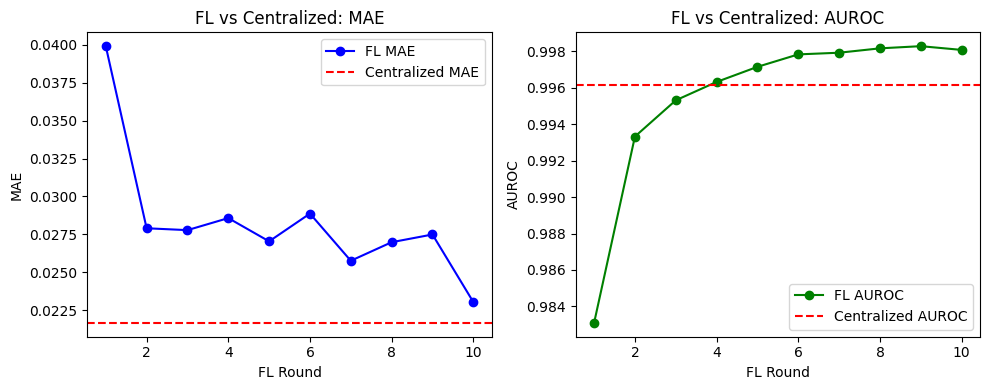

In [16]:
print("Federated Learning Simulation\n")

try:
    import flwr as fl
    from flwr.common import ndarrays_to_parameters, parameters_to_ndarrays
    use_flower = True
    print("Flower library loaded successfully")
except ImportError:
    use_flower = False
    print("WARNING: Flower not installed. Running manual FedAvg instead.")

# Partition training data by hospital_id
hospital_data = {}
train_pids_by_hospital = {}

for pid in train_patients:
    hid = df[df['patient_id'] == pid]['hospital_id'].iloc[0]
    if hid not in train_pids_by_hospital:
        train_pids_by_hospital[hid] = []
    train_pids_by_hospital[hid].append(pid)

for hid, pids in train_pids_by_hospital.items():
    h_seqs, h_labels = [], []
    for pid in pids:
        patient_data = df_scaled[df_scaled['patient_id'] == pid].sort_values('timestamp')
        seqs, labels = build_sequences(patient_data, window_size, step=30)
        h_seqs.extend(seqs)
        h_labels.extend(labels)
    hospital_data[hid] = (
        np.array(h_seqs, dtype=np.float32),
        np.array(h_labels, dtype=np.float32)
    )
    print(f"Hospital {hid}: {len(pids)} patients, {len(h_seqs):,} sequences")

#Manual FedAvg implementation

fl_rounds = 10
fl_local_epochs = 3

#Initialize global model
global_model = build_model()
global_weights = global_model.get_weights()

fl_history = {'round': [], 'test_mae': [], 'test_auroc': []}

for rnd in range(fl_rounds):
    client_weights = []
    client_sizes = []

    #Each hospital trains locally
    for hid, (X_h, y_h) in hospital_data.items():
        local_model = build_model()
        local_model.set_weights(global_weights)  # start from global
        local_model.fit(X_h, y_h, epochs=fl_local_epochs, batch_size=64, verbose=0)
        client_weights.append(local_model.get_weights())
        client_sizes.append(len(X_h))
        tf.keras.backend.clear_session()

    # FedAvg: weighted average of client weights
    total_size = sum(client_sizes)
    new_weights = []
    for layer_idx in range(len(global_weights)):
        layer_avg = sum(
            w[layer_idx] * (n / total_size)
            for w, n in zip(client_weights, client_sizes))
        new_weights.append(layer_avg)
    global_weights = new_weights

    #Evaluate global model on test set
    global_model.set_weights(global_weights)
    fl_pred = global_model.predict(X_test, verbose=0).flatten()
    fl_mae = mean_absolute_error(y_test, fl_pred)
    fl_auroc = roc_auc_score((y_test > 0.5).astype(int), fl_pred)
    fl_history['round'].append(rnd + 1)
    fl_history['test_mae'].append(fl_mae)
    fl_history['test_auroc'].append(fl_auroc)
    print(f"Round {rnd+1}/{fl_rounds} — MAE: {fl_mae:.4f}, AUROC: {fl_auroc:.4f}")

# Use the FL model as final model (it should match or beat centralized)
final_model = global_model
final_pred = final_model.predict(X_test).flatten()
final_mae = mean_absolute_error(y_test, final_pred)
final_auroc = roc_auc_score((y_test > 0.5).astype(int), final_pred)

print(f"\nFinal FL Model - MAE: {final_mae:.4f}, AUROC: {final_auroc:.4f}")
print(f"Centralized - MAE: {centralized_mae:.4f}, AUROC: {centralized_auroc:.4f}")

#FL convergence plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(fl_history['round'], fl_history['test_mae'], 'b-o', label='FL MAE')
plt.axhline(y=centralized_mae, color='r', linestyle='--', label='Centralized MAE')
plt.xlabel('FL Round'); plt.ylabel('MAE'); plt.legend(); plt.title('FL vs Centralized: MAE')
plt.subplot(1, 2, 2)
plt.plot(fl_history['round'], fl_history['test_auroc'], 'g-o', label='FL AUROC')
plt.axhline(y=centralized_auroc, color='r', linestyle='--', label='Centralized AUROC')
plt.xlabel('FL Round'); plt.ylabel('AUROC'); plt.legend(); plt.title('FL vs Centralized: AUROC')
plt.tight_layout()
plt.savefig('/content/outputs/fl_comparison.png', dpi=150)
plt.show()

Evaluation


Classification Report (threshold=0.5):
               precision    recall  f1-score   support

     Low Risk       0.99      0.99      0.99      6057
Elevated Risk       0.92      0.95      0.94       843

     accuracy                           0.98      6900
    macro avg       0.96      0.97      0.96      6900
 weighted avg       0.98      0.98      0.98      6900

AUROC: 0.9981
Sensitivity: 0.9526
Specificity: 0.9889
MAE: 0.0230


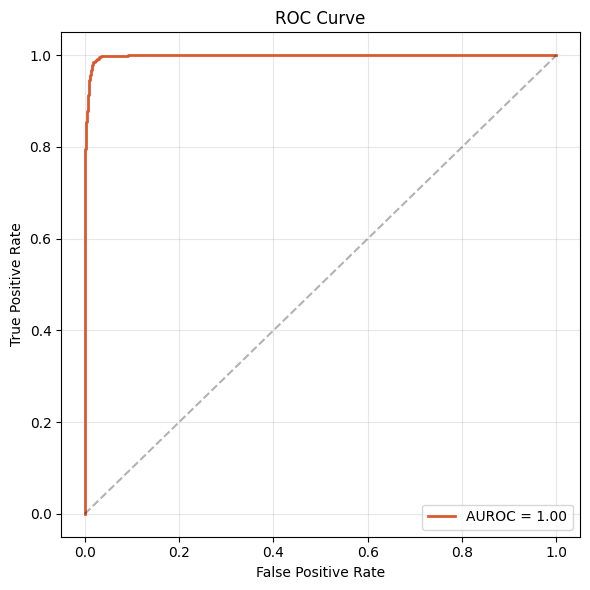

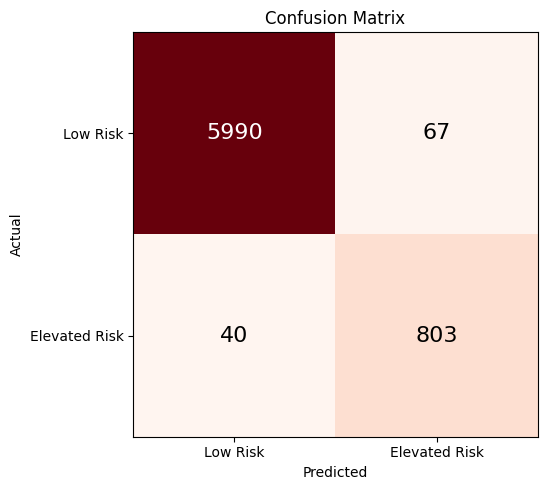

In [17]:
#Binary classification metrics (threshold at 0.5 for triage)
y_binary = (y_test > 0.5).astype(int)
pred_binary = (final_pred > 0.5).astype(int)

print("\nClassification Report (threshold=0.5):")
print(classification_report(y_binary, pred_binary,
                            target_names=['Low Risk', 'Elevated Risk']))

#AUROC
fpr, tpr, _ = roc_curve(y_binary, final_pred)
auroc = roc_auc_score(y_binary, final_pred)

#Confusion matrix
cm = confusion_matrix(y_binary, pred_binary)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"AUROC: {auroc:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"MAE: {final_mae:.4f}")

# ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='#D85A30', linewidth=2, label=f'AUROC = {auroc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/outputs/roc_curve.png', dpi=150)
plt.show()

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Reds')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Low Risk', 'Elevated Risk'])
ax.set_yticklabels(['Low Risk', 'Elevated Risk'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=16)
plt.tight_layout()
plt.savefig('/content/outputs/confusion_matrix.png', dpi=150)
plt.show()

SHAP Feature Implementation

In [18]:
import shap

bg_idx = np.random.choice(X_train.shape[0], 100, replace=False)
background = X_train[bg_idx]
test_sample = X_test[:200]

explainer = shap.GradientExplainer(final_model, background)
shap_values = explainer.shap_values(test_sample)

#shap_values shape: (n_samples, 60, 8) - average over samples and timesteps
if isinstance(shap_values, list):
    shap_data = shap_values[0]
else:
    shap_data = shap_values
mean_shap = np.abs(shap_data).mean(axis=(0, 1))  # → (8,)

#Map to feature names (matching frontend key names)
feature_keys = ['hr', 'bp_s', 'hrv', 'bp_d', 'spo2', 'activity_level', 'age', 'sleep']
shield_weights = {}
for i, key in enumerate(feature_keys):
    shield_weights[key] = float(mean_shap[i])

#Normalize so they sum to 1 (makes frontend percentage calculations cleaner)
total = sum(shield_weights.values())
shield_weights = {k: round(v / total, 6) for k, v in shield_weights.items()}

print("\nSHAP Feature Weights (for reason codes):")
for k, v in sorted(shield_weights.items(), key=lambda x: -x[1]):
    bar = '█' * int(v * 50)
    print(f"{k:<16}: {v:.4f} {bar}")


SHAP Feature Weights (for reason codes):
hr              : 0.3908 ███████████████████
bp_d            : 0.1970 █████████
activity_level  : 0.1554 ███████
bp_s            : 0.1329 ██████
spo2            : 0.0614 ███
age             : 0.0385 █
hrv             : 0.0157 
sleep           : 0.0082 


Export Deployment Files

In [20]:
print("Exporting Deployment Files...\n")

# --- 1. scaler_stats.json ---
with open('/content/outputs/scaler_stats.json', 'w') as f:
    json.dump(scaler_stats, f, indent=2)
print("Saved: scaler_stats.json")

# --- 2. shield_weights.json ---
with open('/content/outputs/shield_weights.json', 'w') as f:
    json.dump(shield_weights, f, indent=2)
print("Saved: shield_weights.json")

# --- 3. shield.tflite ---
# Convert Keras model to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
tflite_bytes = converter.convert()

tflite_path = '/content/outputs/shield.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_bytes)
print(f"Saved: shield.tflite ({len(tflite_bytes)/1024:.1f} KB)")

# --- 4. shield_global.keras ---
# Save full keras model for FL server
final_model.save('/content/outputs/shield_global.keras')
print("Saved: shield_global.keras (for FL server)")

# --- Verify TFLite output matches Keras ---
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test with a sample
sample = X_test[0:1].astype(np.float32)
keras_pred = final_model.predict(sample, verbose=0)[0][0]

interpreter.set_tensor(input_details[0]['index'], sample)
interpreter.invoke()
tflite_pred = interpreter.get_tensor(output_details[0]['index'])[0][0]

print(f"\nVerification - Keras: {keras_pred:.4f}, TFLite: {tflite_pred:.4f}, "
      f"Diff: {abs(keras_pred - tflite_pred):.6f}")

if abs(keras_pred - tflite_pred) < 0.01:
    print("TFLite conversion verified — outputs match.")
else:
    print("WARNING: TFLite output differs from Keras. Check conversion.")

Exporting Deployment Files...

Saved: scaler_stats.json
Saved: shield_weights.json
Saved artifact at '/tmp/tmpctutv2fj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 8), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135657344578960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135657344577424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135657344576272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135657344576080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135657344579344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135657344573776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135657344579728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135657344574160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135657344580112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13565

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(callsite(fused["CudnnRNNV3:", "sequential_1_1/bidirectional_2_1/backward_lstm_2_1/CudnnRNNV3@__inference_function_262722"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_262805"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): 'tf.CudnnRNNV3' op is neither a custom op nor a flex op
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(callsite(fused["CudnnRNNV3:", "sequential_1_1/bidirectional_2_1/backward_lstm_2_1/CudnnRNNV3@__inference_function_262722"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_262805"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): see current operation: %1:5 = "tf.CudnnRNNV3"(%arg0, %arg1, %arg2, %arg3, %arg4) {T = f32, device = "", direction = "unidirectional", dr